In [1]:
# Problema: Decidir cuánta protección adicional contra inundaciones construir hoy, equilibrando su costo con la reducción de la probabilidad de una pérdida futura rara y catastrófica.
# La proteccion cuesta hoy; el riesgo de inundacion es raro pero catastrofico si no se invierte.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
from scipy.optimize import minimize_scalar

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["protection_parameters.csv"])

['protection_parameters.csv']

In [2]:
# Caso sintetico inspirado en la logica economica de la planeacion de diques holandesa; no son datos reales.

parameters = pd.read_csv(data_dir / "protection_parameters.csv")
params = dict(zip(parameters.parameter, parameters.value.astype(float)))
p0, alpha, D, k, h_max = params["p0"], params["alpha"], params["D"], params["k"], params["h_max"]
display(parameters)

,parameter,value
0,p0,1.000000e-02
1,alpha,1.000000e+00
2,D,5.000000e+08
3,k,5.000000e+05
4,h_max,6.000000e+00


In [3]:
# Los parametros deben describir un problema economico bien planteado antes de decidir nada.

assert 0 < p0 < 1
assert alpha > 0
assert D > 0
assert k > 0
assert h_max > 0
print(f"p0={p0}; alpha={alpha}; D={D:,.0f}; k={k:,.0f}; h_max={h_max} m.")

p0=0.01; alpha=1.0; D=500,000,000; k=500,000; h_max=6.0 m.


In [4]:
# El periodo de retorno es el inverso de la probabilidad anual; no es un reloj de recurrencia exacta.

def flood_probability(h):
    return p0 * np.exp(-alpha * h)

def return_period(h):
    p = flood_probability(h)
    return 1 / p if p > 0 else np.inf

def expected_annual_loss(h):
    return D * flood_probability(h)

def annualized_protection_cost(h):
    return k * h

def total_annual_cost(h):
    return annualized_protection_cost(h) + expected_annual_loss(h)

print("Funciones de riesgo y costo definidas: probabilidad, periodo de retorno, costo y perdida esperada.")

Funciones de riesgo y costo definidas: probabilidad, periodo de retorno, costo y perdida esperada.


In [5]:
# Sin inversion adicional, el riesgo anual ya es significativo: la proteccion cero tambien es cara.

baseline_probability = flood_probability(0.0)
baseline_return_period = return_period(0.0)
baseline_cost = annualized_protection_cost(0.0)
baseline_loss = expected_annual_loss(0.0)
baseline_total = total_annual_cost(0.0)
display(
    pd.Series(
        {
            "annual_flood_probability": baseline_probability,
            "return_period_years": baseline_return_period,
            "protection_cost": baseline_cost,
            "expected_annual_loss": baseline_loss,
            "total_annual_cost": baseline_total,
        }
    )
)

annual_flood_probability          0.01
return_period_years             100.00
protection_cost                   0.00
expected_annual_loss        5000000.00
total_annual_cost           5000000.00
dtype: float64

In [6]:
# Evaluamos una malla gruesa de niveles de proteccion; esto no es una busqueda exhaustiva del espacio continuo.

grid_h = np.arange(0.0, h_max + 0.5, 0.5)
protection_grid = pd.DataFrame(
    {
        "h_m": grid_h,
        "annual_flood_probability": [flood_probability(h) for h in grid_h],
        "return_period_years": [return_period(h) for h in grid_h],
        "protection_cost": [annualized_protection_cost(h) for h in grid_h],
        "expected_annual_loss": [expected_annual_loss(h) for h in grid_h],
        "total_annual_cost": [total_annual_cost(h) for h in grid_h],
    }
)
display(protection_grid)

,h_m,annual_flood_probability,return_period_years,protection_cost,expected_annual_loss,total_annual_cost
0,0.0,0.010000,100.000000,0.0,5.000000e+06,5.000000e+06
1,0.5,0.006065,164.872127,250000.0,3.032653e+06,3.282653e+06
2,1.0,0.003679,271.828183,500000.0,1.839397e+06,2.339397e+06
3,1.5,0.002231,448.168907,750000.0,1.115651e+06,1.865651e+06
4,2.0,0.001353,738.905610,1000000.0,6.766764e+05,1.676676e+06
5,2.5,0.000821,1218.249396,1250000.0,4.104250e+05,1.660425e+06
6,3.0,0.000498,2008.553692,1500000.0,2.489353e+05,1.748935e+06
7,3.5,0.000302,3311.545196,1750000.0,1.509869e+05,1.900987e+06
8,4.0,0.000183,5459.815003,2000000.0,9.157819e+04,2.091578e+06
9,4.5,0.000111,9001.713130,2250000.0,5.554498e+04,2.305545e+06


In [7]:
# El mejor punto de la malla aproxima el optimo, pero no lo garantiza.

grid_best_row = protection_grid.loc[protection_grid.total_annual_cost.idxmin()]
grid_best_h = float(grid_best_row.h_m)
print(f"Mejor punto de la malla: h={grid_best_h:.1f} m; costo total {grid_best_row.total_annual_cost:,.0f}")

Mejor punto de la malla: h=2.5 m; costo total 1,660,425


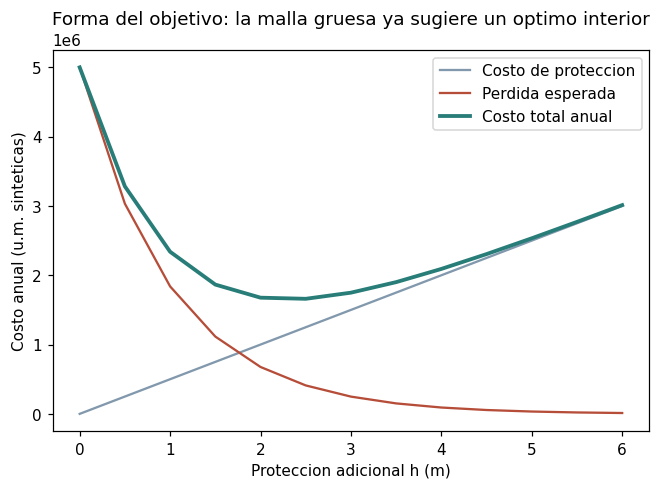

In [8]:
# El costo de proteccion sube, la perdida esperada baja: la suma forma una curva en U con un optimo interior.

fig_shape, ax_shape = plt.subplots(figsize=(7, 4.5))
ax_shape.plot(protection_grid.h_m, protection_grid.protection_cost, label="Costo de proteccion", color="#8299ad")
ax_shape.plot(protection_grid.h_m, protection_grid.expected_annual_loss, label="Perdida esperada", color="#b64d39")
ax_shape.plot(
    protection_grid.h_m, protection_grid.total_annual_cost, label="Costo total anual",
    color="#287d78", linewidth=2.5,
)
ax_shape.set(
    xlabel="Proteccion adicional h (m)", ylabel="Costo anual (u.m. sinteticas)",
    title="Forma del objetivo: la malla gruesa ya sugiere un optimo interior",
)
ax_shape.legend()
plt.show()

In [9]:
# Referencia de ingenieria: una regla fija de altura, no un estandar real declarado.

engineering_rule_h = 1.5
engineering_rule_probability = flood_probability(engineering_rule_h)
engineering_rule_return_period = return_period(engineering_rule_h)
engineering_rule_cost = annualized_protection_cost(engineering_rule_h)
engineering_rule_loss = expected_annual_loss(engineering_rule_h)
engineering_rule_total = total_annual_cost(engineering_rule_h)
print(f"Regla de ingenieria (h={engineering_rule_h} m): costo total {engineering_rule_total:,.0f}")

Regla de ingenieria (h=1.5 m): costo total 1,865,651


In [10]:
# Referencia conservadora: proteccion alta, cercana al limite constructivo.

conservative_high_h = 5.0
conservative_high_probability = flood_probability(conservative_high_h)
conservative_high_return_period = return_period(conservative_high_h)
conservative_high_cost = annualized_protection_cost(conservative_high_h)
conservative_high_loss = expected_annual_loss(conservative_high_h)
conservative_high_total = total_annual_cost(conservative_high_h)
print(f"Proteccion conservadora (h={conservative_high_h} m): costo total {conservative_high_total:,.0f}")

Proteccion conservadora (h=5.0 m): costo total 2,533,690


In [11]:
# Cuatro referencias, un mismo criterio: costo total anual esperado.

reference_preview = pd.DataFrame(
    [
        [
            "no_additional_protection", 0.0, baseline_probability, baseline_return_period,
            baseline_cost, baseline_loss, baseline_total,
        ],
        [
            "engineering_rule", engineering_rule_h, engineering_rule_probability, engineering_rule_return_period,
            engineering_rule_cost, engineering_rule_loss, engineering_rule_total,
        ],
        [
            "conservative_high", conservative_high_h, conservative_high_probability, conservative_high_return_period,
            conservative_high_cost, conservative_high_loss, conservative_high_total,
        ],
        [
            "grid_best", grid_best_h, grid_best_row.annual_flood_probability, grid_best_row.return_period_years,
            grid_best_row.protection_cost, grid_best_row.expected_annual_loss, grid_best_row.total_annual_cost,
        ],
    ],
    columns=[
        "strategy", "h_m", "annual_flood_probability", "return_period_years",
        "protection_cost", "expected_annual_loss", "total_annual_cost",
    ],
)
display(reference_preview)

,strategy,h_m,annual_flood_probability,return_period_years,protection_cost,expected_annual_loss,total_annual_cost
0,no_additional_protection,0.0,0.010000,100.000000,0.0,5.000000e+06,5.000000e+06
1,engineering_rule,1.5,0.002231,448.168907,750000.0,1.115651e+06,1.865651e+06
2,conservative_high,5.0,0.000067,14841.315910,2500000.0,3.368973e+04,2.533690e+06
3,grid_best,2.5,0.000821,1218.249396,1250000.0,4.104250e+05,1.660425e+06


In [12]:
# La variable de decision es continua y el objetivo contiene exp(-alpha*h): el modelo es no lineal.

print("La variable de decision h es continua, no discreta.")
print("El objetivo incluye exp(-alpha*h): no es una funcion lineal de h.")
print("PuLP + HiGHS resuelve programas lineales/enteros; no es el solver adecuado aqui.")
print("El metodo numerico debe corresponder a la estructura matematica del problema.")

La variable de decision h es continua, no discreta.
El objetivo incluye exp(-alpha*h): no es una funcion lineal de h.
PuLP + HiGHS resuelve programas lineales/enteros; no es el solver adecuado aqui.
El metodo numerico debe corresponder a la estructura matematica del problema.


In [13]:
# MODEL
# ---------------------------------------------------------------------
# Parameters:
#   p0       baseline annual flood probability
#   alpha    protection effectiveness per metre
#   D        flood consequence
#   k        annualized protection cost per metre
#   h_max    maximum feasible additional protection height
#
# Decision variable:
#   h continuous
#       0 <= h <= h_max
#
# Derived:
#   p(h) = p0 * exp(-alpha * h)
#
#   expected_loss(h) =
#       D * p(h)
#
#   protection_cost(h) =
#       k * h
#
# Objective:
#   minimize total_annual_cost:
#       protection_cost(h)
#       + expected_loss(h)

display(pd.Series({"decision_variables": 1, "lower_bound": 0.0, "upper_bound": h_max}))

decision_variables    1.0
lower_bound           0.0
upper_bound           6.0
dtype: float64

In [14]:
# Resolvemos el modelo continuo no lineal con un optimizador escalar acotado.

result = minimize_scalar(
    total_annual_cost,
    bounds=(0.0, h_max),
    method="bounded",
)
assert result.success
optimized_h = result.x
optimized_total_cost = result.fun
optimized_probability = flood_probability(optimized_h)
optimized_return_period = return_period(optimized_h)
optimized_protection_cost = annualized_protection_cost(optimized_h)
optimized_expected_loss = expected_annual_loss(optimized_h)
display(
    pd.Series(
        {
            "optimized_h_m": optimized_h,
            "optimized_total_cost": optimized_total_cost,
            "optimized_probability": optimized_probability,
            "optimized_return_period_years": optimized_return_period,
        }
    )
)
print(f"SciPy exito: {result.success}; h*={optimized_h:.6f} m; costo total {optimized_total_cost:,.2f}")

optimized_h_m                    2.302584e+00
optimized_total_cost             1.651293e+06
optimized_probability            1.000001e-03
optimized_return_period_years    9.999991e+02
dtype: float64

SciPy exito: True; h*=2.302584 m; costo total 1,651,292.55


In [15]:
# La condicion de primer orden tiene forma cerrada para este caso particular: la usamos como validacion.

if alpha * D * p0 > k:
    h_analytical = (1 / alpha) * np.log(alpha * D * p0 / k)
    h_analytical = min(h_analytical, h_max)
else:
    h_analytical = 0.0
assert np.isclose(optimized_h, h_analytical, atol=1e-4)
print(f"Optimo analitico: h={h_analytical:.6f} m; optimo numerico: h={optimized_h:.6f} m.")

Optimo analitico: h=2.302585 m; optimo numerico: h=2.302584 m.


In [16]:
# La segunda derivada es positiva en todo el dominio: verificamos convexidad estricta en una malla determinista.

convexity_grid = np.linspace(0.0, h_max, 61)
second_derivative_grid = alpha**2 * D * p0 * np.exp(-alpha * convexity_grid)
assert np.all(second_derivative_grid > 0)
print(f"Segunda derivada minima en [0, h_max]: {second_derivative_grid.min():,.2f} > 0 -> convexidad estricta confirmada.")

Segunda derivada minima en [0, h_max]: 12,393.76 > 0 -> convexidad estricta confirmada.


In [17]:
# Una probabilidad anual baja no impide que una inversion sustancial sea economicamente justificada.

print(f"Base (h=0): probabilidad {baseline_probability:.4f}; periodo de retorno {baseline_return_period:.0f} anios.")
print(f"Optimo (h={optimized_h:.2f}): probabilidad {optimized_probability:.4f}; periodo de retorno {optimized_return_period:.0f} anios.")
print("El periodo de retorno es una medida de probabilidad anual inversa, no una recurrencia garantizada.")

Base (h=0): probabilidad 0.0100; periodo de retorno 100 anios.
Optimo (h=2.30): probabilidad 0.0010; periodo de retorno 1000 anios.
El periodo de retorno es una medida de probabilidad anual inversa, no una recurrencia garantizada.


In [18]:
# En el optimo, el costo marginal de proteccion iguala la reduccion marginal de la perdida esperada.

marginal_cost = k
marginal_loss_reduction = alpha * D * p0 * np.exp(-alpha * optimized_h)
assert np.isclose(marginal_cost, marginal_loss_reduction, rtol=1e-3)
print(f"Costo marginal: {marginal_cost:,.2f}; reduccion marginal de perdida esperada: {marginal_loss_reduction:,.2f}")

Costo marginal: 500,000.00; reduccion marginal de perdida esperada: 500,000.43


In [19]:
# Validamos el optimo de forma independiente antes de compararlo con las referencias.

assert 0 <= optimized_h <= h_max
assert result.success
recomputed_total = total_annual_cost(optimized_h)
assert np.isclose(recomputed_total, optimized_total_cost)
assert optimized_total_cost < baseline_total
assert optimized_total_cost <= engineering_rule_total
assert optimized_total_cost <= conservative_high_total
assert optimized_total_cost <= grid_best_row.total_annual_cost
probe_h = np.linspace(0, h_max, 25)
probe_probability = [flood_probability(h) for h in probe_h]
probe_cost = [annualized_protection_cost(h) for h in probe_h]
probe_loss = [expected_annual_loss(h) for h in probe_h]
assert all(np.diff(probe_probability) <= 0)
assert all(np.diff(probe_cost) >= 0)
assert all(np.diff(probe_loss) <= 0)
print("Validado: optimo factible, mejor que todas las referencias, y monotonicidad confirmada.")

Validado: optimo factible, mejor que todas las referencias, y monotonicidad confirmada.


In [20]:
# Mayor consecuencia potencial de inundacion justifica mayor proteccion economica.

def solve_total_cost(p0_, alpha_, D_, k_, h_max_):
    def cost_fn(h):
        return k_ * h + D_ * p0_ * np.exp(-alpha_ * h)
    res = minimize_scalar(cost_fn, bounds=(0.0, h_max_), method="bounded")
    assert res.success
    return res.x, res.fun

def analytical_h(p0_, alpha_, D_, k_, h_max_):
    if alpha_ * D_ * p0_ > k_:
        return min((1 / alpha_) * np.log(alpha_ * D_ * p0_ / k_), h_max_)
    return 0.0

d_sensitivity_rows = []
for D_value in [250_000_000, 500_000_000, 1_000_000_000]:
    h_star, total_star = solve_total_cost(p0, alpha, D_value, k, h_max)
    h_star_analytical = analytical_h(p0, alpha, D_value, k, h_max)
    assert np.isclose(h_star, h_star_analytical, atol=1e-4)
    d_sensitivity_rows.append(
        [D_value, h_star, flood_probability(h_star), return_period(h_star), total_star]
    )
d_sensitivity = pd.DataFrame(
    d_sensitivity_rows,
    columns=["D", "optimized_h_m", "annual_flood_probability", "return_period_years", "optimized_total_cost"],
)
display(d_sensitivity)

,D,optimized_h_m,annual_flood_probability,return_period_years,optimized_total_cost
0,250000000,1.609438,0.0020,500.000233,1.304719e+06
1,500000000,2.302584,0.0010,999.999131,1.651293e+06
2,1000000000,2.995731,0.0005,1999.996820,1.997866e+06


In [21]:
# Proteccion mas costosa reduce el nivel de proteccion economicamente optimo.

k_sensitivity_rows = []
for k_value in [350_000, 500_000, 750_000]:
    h_star, total_star = solve_total_cost(p0, alpha, D, k_value, h_max)
    h_star_analytical = analytical_h(p0, alpha, D, k_value, h_max)
    assert np.isclose(h_star, h_star_analytical, atol=1e-4)
    k_sensitivity_rows.append(
        [k_value, h_star, flood_probability(h_star), return_period(h_star), total_star]
    )
k_sensitivity = pd.DataFrame(
    k_sensitivity_rows,
    columns=["k", "optimized_h_m", "annual_flood_probability", "return_period_years", "optimized_total_cost"],
)
display(k_sensitivity)

,k,optimized_h_m,annual_flood_probability,return_period_years,optimized_total_cost
0,350000,2.659260,0.0007,1428.571393,1.280741e+06
1,500000,2.302584,0.0010,999.999131,1.651293e+06
2,750000,1.897120,0.0015,666.666443,2.172840e+06


In [22]:
# Combinamos ambas dimensiones de sensibilidad en una sola tabla compacta.

risk_sensitivity = pd.concat(
    [
        d_sensitivity.assign(varied_parameter="D", parameter_value=d_sensitivity.D).drop(columns="D"),
        k_sensitivity.assign(varied_parameter="k", parameter_value=k_sensitivity.k).drop(columns="k"),
    ],
    ignore_index=True,
)[
    [
        "varied_parameter", "parameter_value", "optimized_h_m",
        "annual_flood_probability", "return_period_years", "optimized_total_cost",
    ]
]
display(risk_sensitivity)

,varied_parameter,parameter_value,optimized_h_m,annual_flood_probability,return_period_years,optimized_total_cost
0,D,250000000,1.609438,0.0020,500.000233,1.304719e+06
1,D,500000000,2.302584,0.0010,999.999131,1.651293e+06
2,D,1000000000,2.995731,0.0005,1999.996820,1.997866e+06
3,k,350000,2.659260,0.0007,1428.571393,1.280741e+06
4,k,500000,2.302584,0.0010,999.999131,1.651293e+06
5,k,750000,1.897120,0.0015,666.666443,2.172840e+06


In [23]:
# El optimo supera a todas las referencias fijas bajo el mismo criterio economico.

investment_comparison = pd.concat(
    [
        reference_preview,
        pd.DataFrame(
            [
                [
                    "optimized", optimized_h, optimized_probability, optimized_return_period,
                    optimized_protection_cost, optimized_expected_loss, optimized_total_cost,
                ]
            ],
            columns=reference_preview.columns,
        ),
    ],
    ignore_index=True,
)
investment_comparison["gap_vs_optimized"] = investment_comparison.total_annual_cost - optimized_total_cost
display(investment_comparison)

,strategy,h_m,annual_flood_probability,return_period_years,protection_cost,expected_annual_loss,total_annual_cost,gap_vs_optimized
0,no_additional_protection,0.000000,0.010000,100.000000,0.000000e+00,5.000000e+06,5.000000e+06,3.348707e+06
1,engineering_rule,1.500000,0.002231,448.168907,7.500000e+05,1.115651e+06,1.865651e+06,2.143583e+05
2,conservative_high,5.000000,0.000067,14841.315910,2.500000e+06,3.368973e+04,2.533690e+06,8.823972e+05
3,grid_best,2.500000,0.000821,1218.249396,1.250000e+06,4.104250e+05,1.660425e+06,9.132447e+03
4,optimized,2.302584,0.001000,999.999131,1.151292e+06,5.000004e+05,1.651293e+06,0.000000e+00


In [24]:
# Curva fina para el artefacto de entrega, distinta de la malla pedagogica gruesa.

fine_h = np.round(np.arange(0.0, h_max + 0.1, 0.1), 2)
protection_curve = pd.DataFrame(
    {
        "h_m": fine_h,
        "annual_flood_probability": [flood_probability(h) for h in fine_h],
        "return_period_years": [return_period(h) for h in fine_h],
        "protection_cost": [annualized_protection_cost(h) for h in fine_h],
        "expected_annual_loss": [expected_annual_loss(h) for h in fine_h],
        "total_annual_cost": [total_annual_cost(h) for h in fine_h],
    }
)
display(protection_curve.head())

,h_m,annual_flood_probability,return_period_years,protection_cost,expected_annual_loss,total_annual_cost
0,0.0,0.010000,100.000000,0.0,5.000000e+06,5.000000e+06
1,0.1,0.009048,110.517092,50000.0,4.524187e+06,4.574187e+06
2,0.2,0.008187,122.140276,100000.0,4.093654e+06,4.193654e+06
3,0.3,0.007408,134.985881,150000.0,3.704091e+06,3.854091e+06
4,0.4,0.006703,149.182470,200000.0,3.351600e+06,3.551600e+06


In [25]:
# Construimos el planeador sin mostrarlo hasta completar todas sus capas.

planner = Figure(figsize=(10, 7), layout="constrained")
planner_ax = planner.add_subplot(111)
planner_ax.plot(protection_curve.h_m, protection_curve.protection_cost, color="#8299ad", label="Costo de proteccion")
planner_ax.plot(protection_curve.h_m, protection_curve.expected_annual_loss, color="#b64d39", label="Perdida esperada")
planner_ax.plot(
    protection_curve.h_m, protection_curve.total_annual_cost, color="#287d78",
    linewidth=2.5, label="Costo total anual",
)

planner_ax.axvline(optimized_h, color="#287d78", linestyle="--", linewidth=1, alpha=0.7)
planner_ax.scatter([optimized_h], [optimized_total_cost], color="#287d78", s=90, zorder=5, label="Optimo")
planner_ax.scatter(
    [0.0], [baseline_total], color="#b64d39", s=90, marker="s", zorder=5, label="Sin proteccion adicional"
)

planner_ax.set(xlabel="Proteccion adicional h (m)", ylabel="Costo anual (u.m. sinteticas)");

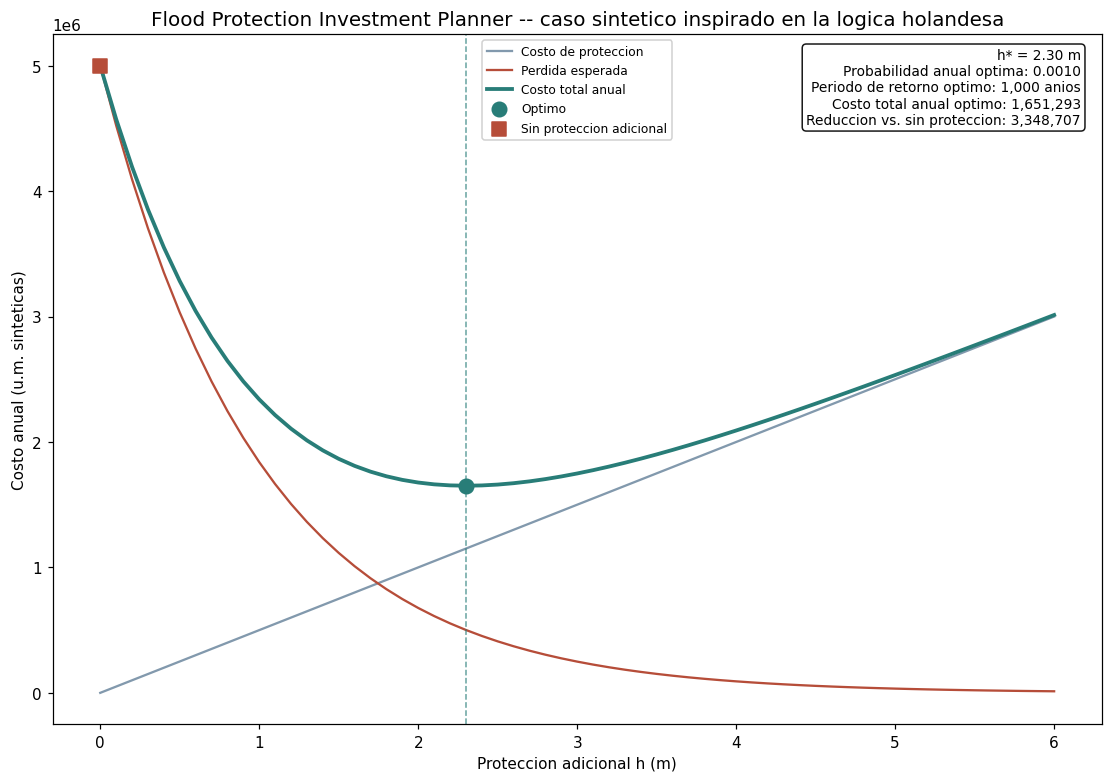

In [26]:
# El planeador completo es el producto de decision: cuanta proteccion construir y por que.

planner_ax.set_title("Flood Protection Investment Planner -- caso sintetico inspirado en la logica holandesa", fontsize=13)
planner_ax.legend(loc="upper center", fontsize=8, framealpha=0.9)
summary_text = (
    f"h* = {optimized_h:.2f} m\n"
    f"Probabilidad anual optima: {optimized_probability:.4f}\n"
    f"Periodo de retorno optimo: {optimized_return_period:,.0f} anios\n"
    f"Costo total anual optimo: {optimized_total_cost:,.0f}\n"
    f"Reduccion vs. sin proteccion: {baseline_total - optimized_total_cost:,.0f}"
)
planner_ax.text(
    0.98, 0.98, summary_text, transform=planner_ax.transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
)
display(planner)

In [27]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert np.isclose(baseline_probability, 0.01)
assert np.isclose(baseline_loss, 5_000_000)
assert np.isclose(baseline_total, 5_000_000)
assert result.success
assert np.isclose(optimized_h, 2.302585, atol=1e-3)
assert np.isclose(optimized_h, h_analytical, atol=1e-4)
assert np.isclose(optimized_probability, 0.001, atol=1e-4)
assert np.isclose(optimized_return_period, 1000, rtol=1e-2)
assert optimized_total_cost < baseline_total
assert optimized_total_cost <= engineering_rule_total
assert optimized_total_cost <= conservative_high_total
assert optimized_total_cost <= grid_best_row.total_annual_cost
assert d_sensitivity.optimized_h_m.diff().dropna().gt(0).all()
assert d_sensitivity.optimized_total_cost.diff().dropna().gt(0).all()
assert k_sensitivity.optimized_h_m.diff().dropna().lt(0).all()
print("Verificado: optimo numerico, validacion analitica, condicion marginal y sensibilidad consistentes.")

Verificado: optimo numerico, validacion analitica, condicion marginal y sensibilidad consistentes.


In [28]:
# Guardamos la curva, la comparacion de estrategias, la sensibilidad y el planeador; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
protection_curve.to_csv(submission_dir / "protection_curve.csv", index=False)
investment_comparison.to_csv(submission_dir / "investment_comparison.csv", index=False)
risk_sensitivity.to_csv(submission_dir / "risk_sensitivity.csv", index=False)
planner.savefig(
    submission_dir / "flood_protection_investment_planner.png", dpi=180, bbox_inches="tight", facecolor="white"
)
display(
    [
        str(submission_dir / name)
        for name in [
            "protection_curve.csv",
            "investment_comparison.csv",
            "risk_sensitivity.csv",
            "flood_protection_investment_planner.png",
        ]
    ]
)

['../submission/protection_curve.csv',
 '../submission/investment_comparison.csv',
 '../submission/risk_sensitivity.csv',
 '../submission/flood_protection_investment_planner.png']